# Question 13

In [89]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots
from ISLP import load_data
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from ISLP.models import (summarize,
                         ModelSpec as MS)
from ISLP import confusion_table
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

## (a)

In [3]:
weekly = load_data('Weekly')
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [5]:
weekly.tail()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up
1088,2010,1.034,0.283,1.281,2.969,-0.861,2.707105,0.069,Up


In [17]:
weekly.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


In [10]:
weekly.Direction.value_counts()

Direction
Up      605
Down    484
Name: count, dtype: int64

Text(0.5, 1.0, 'Volume')

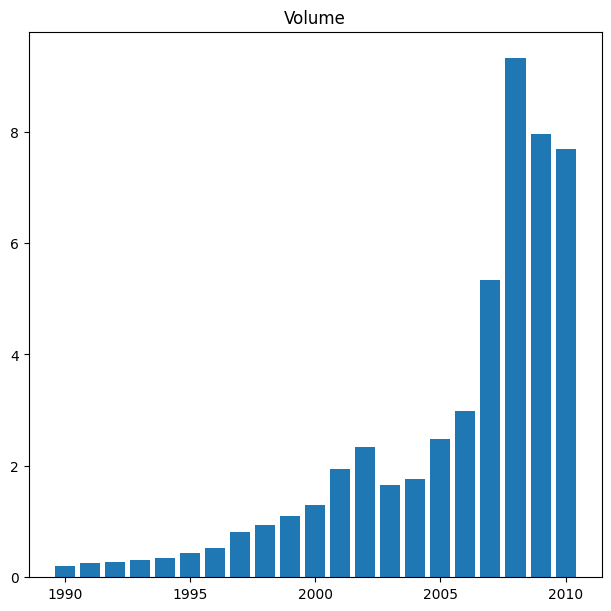

In [33]:
fig, ax = subplots(ncols=1, nrows=1, figsize=(6,6), layout='constrained')
x = weekly.Year
y = weekly.Volume
ax.bar(x, y)
ax.set_title('Volume')

In [31]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


## (b)

In [69]:
X = MS(weekly.drop(columns=['Year', 'Today', 'Direction'])).fit_transform(weekly)
Y = weekly.Direction == 'Up'
Md_1 = sm.GLM(Y,
              X,
              family=sm.families.Binomial())
results = Md_1.fit()
summarize(results)


,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


lag2 appears to be more significant

## (c)

In [71]:
prob = results.predict()
labels = np.array(['Down']*1089, dtype=object)
labels[prob > 0.5] = 'Up'
confusion_table(labels, weekly.Direction)



Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [72]:
np.mean(labels == weekly.Direction)

np.float64(0.5610651974288338)

the accuracy rate is 56% overall but in 430 cases it predicted up when market was down

## (d)

In [83]:
(weekly.Year > 2008).sum()


np.int64(104)

In [130]:
X = weekly['Lag2'].to_frame()
Y = weekly.Direction
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    Y,
                                                    test_size=104,
                                                    shuffle=False)


In [134]:
Model_1 = LogisticRegression()


In [136]:
results_1 = Model_1.fit(x_train, y_train)
pred_1 = results_1.predict(x_test)
confusion_matrix(y_test, pred_1)

array([[ 9, 34],
       [ 5, 56]])